# Level 1 - Task 4: Online Delivery Analysis

## Objective

The objective of this task is to analyze the availability of online delivery services among restaurants and compare customer ratings.

### This task includes:

- Determining the percentage of restaurants offering online delivery.
- Comparing average ratings of restaurants with and without online delivery.
- Visualizing the results using charts.

### Libraries Used

- Pandas
- Matplotlib
- Seaborn

## Step 1: Count Restaurants Offering Online Delivery

This step counts how many restaurants provide online delivery and how many do not.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

In [6]:
df = pd.read_csv("../Dataset.csv")

# Display first five rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [9]:
online_delivery = df["Has Online delivery"].value_counts()

online_delivery

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

## Step 2: Calculate Percentage of Restaurants with Online Delivery

The percentage of restaurants offering online delivery is calculated.

In [12]:
online_percentage = (online_delivery / len(df)) * 100

online_percentage.round(2)

Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64

## Step 3: Create Summary Table

A summary table is created showing restaurant count and percentage.

In [15]:
summary = pd.DataFrame({
    "Online Delivery": online_delivery.index,
    "Restaurant Count": online_delivery.values,
    "Percentage (%)": online_percentage.values.round(2)
})

summary

,Online Delivery,Restaurant Count,Percentage (%)
0,No,7100,74.34
1,Yes,2451,25.66


## Step 4: Compare Average Ratings

This step compares the average aggregate ratings of restaurants that provide online delivery and those that do not.

In [18]:
rating_comparison = (
    df.groupby("Has Online delivery")["Aggregate rating"]
      .mean()
      .round(2)
)

rating_comparison

Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64

## Step 5: Visualize Online Delivery Distribution

The following chart shows the number of restaurants that provide online delivery.

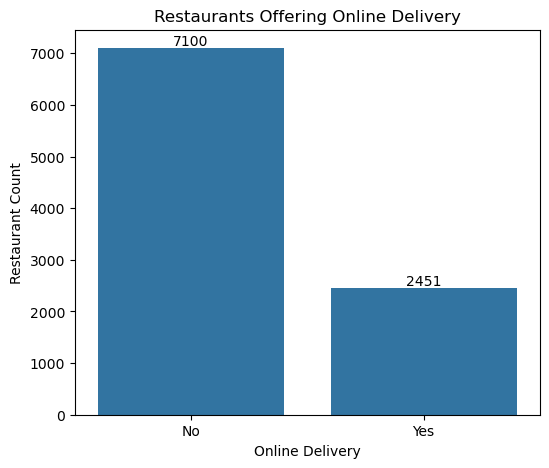

In [21]:
import os

os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=summary,
    x="Online Delivery",
    y="Restaurant Count"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Restaurant Count")

plt.savefig(
    "../images/online_delivery_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 6: Visualize Average Ratings

This chart compares the average ratings of restaurants based on online delivery availability.

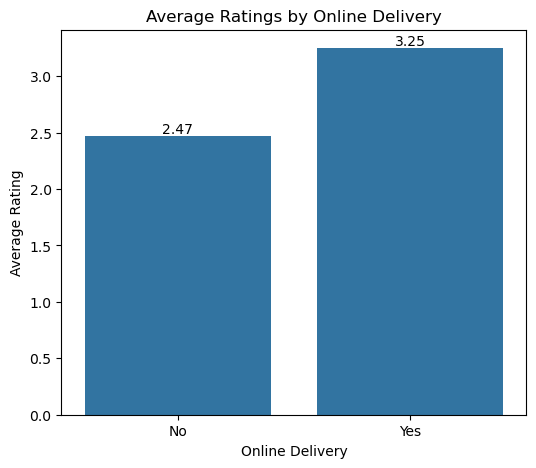

In [26]:
rating_df = rating_comparison.reset_index()
rating_df.columns = ["Online Delivery", "Average Rating"]

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=rating_df,
    x="Online Delivery",
    y="Average Rating"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Ratings by Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

plt.savefig(
    "../images/online_delivery_ratings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insight

- Restaurants offering online delivery may attract more customers due to convenience.
- Comparing ratings helps identify whether online delivery influences customer satisfaction.
- Businesses can use this information to decide whether introducing online delivery could improve customer experience.

# Conclusion

## Key Findings

- The percentage of restaurants offering online delivery was calculated.
- Average ratings of restaurants with and without online delivery were compared.
- Visualizations clearly illustrate both the distribution of online delivery services and the associated average ratings.
- The analysis provides insights into customer preferences and restaurant service offerings.